# Relatório 1: CNC
Métodos de resolução numérica: Bissecção, Falsa Posição, Newton-Raphson e Secante.

## Imports

In [2]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

## Biblioteca de métodos
As quatro funções genéricas, recebendo `f` como parâmetro.

In [3]:
# o intervalo é um vetor de de a até b: [a, b]
# precisão absoluta ε(epsilon)
def bissection(f, a, b, epsilon):
    k = 1
    historico = [] # lista vazia
    x_anterior = None

    # da pra botar limite de iteração com AND k < limite
    while (b - a) > epsilon:
        # descobre o x
        x = (a + b) / 2

        # Calcula erro aproximado (exceto na 1a iteração)
        if x_anterior is None:
            erro_a = None
        else:
            erro_a = abs(x - x_anterior) / abs(x) * 100
            erro_a = round(erro_a, 6) # faz o round aqui pra n usar round com None, q ai da erro

        #guarda os dados da iteração
        historico.append([k, round(a, 4), round(b, 4), round(x, 4), round(f(x), 6), erro_a])

        # avalia f(x) e multiplica por f(a)
        if (f(a)*f(x)) > 0:
            # se f(a).f(x) > 0, então a raiz ta no intervalo [x, b] e não [a, b]
            a = x # ent etualiza o a
        else:
            # se f(a).f(x) < 0, então a raiz ta no intervalo [a, x] e não [a, b]
            b = x # ent atualiza o b

        x_anterior = x # guarda pra calcular o erro relativo percentual
        k = k + 1 #conta quantas iterações o código teve

    # print(k)
    # funciona pq python n tem escopo de bloco, ou seja, while, if, else e afins n criam um escopo novo
    return x, historico

In [4]:
# recebe um intervalo [a, b]
# epsilon1: mede o tamanho do intervalo (b - a)
# epsilon2: mede |f(x)|, que é o quão perto de zero a f(x) já está
def falsepos(f, a, b, epsilon1, epsilon2):
    k = 1
    historico = []
    x_anterior = None

    # se o intervalo já é pequeno o suficiente, retorna o x
    if (b - a) < epsilon1: return (a*f(b) - b*f(a)) / (f(b) - f(a)), historico

    # se algum dos extremos já está suficientemente perto de zero, retorna eles como resultado
    if abs(f(a)) < epsilon2:
        return a, historico
    else:
        if abs(f(b)) < epsilon2: return b, historico

    while (b - a) > epsilon1:
        # calcula o ponto em x que a reta secante corta
        x = (a*f(b) - b*f(a)) / (f(b) - f(a))

        if x_anterior is None:
            erro_a = None
        else:
            erro_a = abs(x - x_anterior) / abs(x) * 100
            erro_a = round(erro_a, 6)

        # guarda dados pra resposta da letra c
        historico.append([k, round(a, 4), round(b, 4), round(x, 4), round(f(x), 6), erro_a])

        if abs(f(x)) < epsilon2: return x, historico

        if (f(a)*f(x)) > 0:
            a = x # ent etualiza o a
        else:
            b = x # ent atualiza o b

        #conta quantas iterações o código teve
        x_anterior = x
        k = k + 1

    # print(k)
    return x, historico

In [5]:
# xi: aproximação inicial
# x: novo candidato pra aproximar
# epsilon1: quão próximo de zero o valor da função já tá. |f(x)|
# epsilon2: distância entre a nova aproximação e a anterior. |x - xi|
# ps: epsilon2 indica o quão próxima a função está de convergir. Se ele n mudou mt significa que ela já convergiu

def newtonraphson(f, xi, epsilon1, epsilon2, expr_fline_builder):
    # expr_fline_builder: função que recebe o símbolo sympy e devolve a expressão simbólica de f,
    # pra biblioteca conseguir derivar simbolicamente sem fixar uma fórmula específica aqui dentro
    k = 1
    historico = []
    primeira_iteracao = True

    if abs(f(xi)) < epsilon1: return xi, historico

    # usa a lib sympy pra criar uma expressão textual da derivada e converter ela pra função python
    symb_v = sp.symbols('x')
    expr_fline = sp.diff(expr_fline_builder(symb_v), symb_v)
    f_line = sp.lambdify(symb_v, expr_fline, "numpy")

    while True:
        # chutamos um ponto x qualquer do plano cartesiano (xi). Pode estar longe ou próximo da raiz x
        # calculamos a derivada da função nesse ponto. Ou seja, a inclinação daquela curva no gráfico.
        # calculamos uma reta usando o ponto atual + derivada (taxa de inclinação) e vemos onde essa reta corta o eixo x.
        # esse x vira nosso próximo x, e ele está mais perto da raiz. Por que a derivada dita a inclinação.
        x = xi - (f(xi)/f_line(xi))

        if primeira_iteracao:
            erro_a = None
            primeira_iteracao = False
        else:
            erro_a = abs(x - xi) / abs(x) * 100
            erro_a = round(erro_a, 6)

        # aqui pode confundir, já que vi no enunciado é meu xi, e vi+1 é o meu x.
        historico.append([k, round(xi, 4), round(f(xi), 6), round(f_line(xi), 6), round(x, 4), erro_a])

        # se já estamos próximos o suficiente de 0 OU já convergiu (já ta próxima suficiente do valor real)
        # caso divirja, o meu newton raphson pode ficar rodando infinito.
        if abs(f(x)) < epsilon1 or abs(x - xi) < epsilon2:
            break

        # se não, move pro x mais próximo da raiz e tenta de novo.
        xi = x
        k = k + 1

    # print(k)
    return x, historico

In [6]:
# os pontos iniciais não precisam cercar a raiz. São dois pontos quaisquer da função
# x0: ponto inicial 1
# x1: ponto inicial 2
# x2: novo ponto candidato, que está mais próximo da raiz

# epsilon1: quão próximo de zero o valor da função já tá. |f(x)|
# epsilon2: distância entre a nova aproximação e a anterior. |x - xi|
def secant(f, x0, x1, epsilon1, epsilon2):

    # inicia as iterações
    k = 1
    historico = []
    primeira_iteracao = True

    # se o primeiro ponto já tá próximo o suficiente de 0, retorna ele
    if abs(f(x0)) < epsilon1: return x0, historico

    # se o segundo ponto já tá próximo suficiente de 0, retorna ele
    if abs(f(x1)) < epsilon1: return x1, historico

    # se os 2 pontos iniciais já estão próximos os suficiente entre si a função convergiu.
    # ou seja, ela n vai chegar mais perto da raiz doq ela já tá. Então retorna x1 que é mais próximo da raiz
    if abs(x1 - x0) < epsilon2: return x1, historico

    while True:
        # bloco1: f(x1) - f(x0). variação em y entre os 2 últimos pontos
        # bloco2: x1 - x0. variação em x entre os 2 últimos pontos
        # inclinação aproximada = bloco1 / bloco2
        # f(x1) / inclinação = quanto preciso andar em x pra reta secante zerar
        # (matematicamente igual a: (f(x1) / bloco1) * bloco2).
        # subtrair isso de x1 nos move na direção certa (esquerda ou direita) rumo à raiz
        x2 = x1 - (f(x1) / (f(x1) - f(x0))) * (x1 - x0)

        if primeira_iteracao:
            erro_a = None
            primeira_iteracao = False
        else:
            erro_a = round(abs(x2 - x1) / abs(x2) * 100, 6)

        historico.append([k, round(x0, 4), round(x1, 4), round(f(x0), 6), round(f(x1), 6), round(x2, 4), erro_a])

        # se o x2(candidato) já tá próximo de zero o suficiente OU
        # se o intervalo entre o último ponto e o próximo já é pequeno suficiente (convergiu)
        # ent retorna x2 q ele já tá próximo suficiente da raiz.
        if abs(f(x2)) < epsilon1 or abs(x2 - x1) < epsilon2:
            print(k)
            return x2, historico

        # se não, move o intervalo dos pontos pra frente
        x0 = x1
        x1 = x2
        k = k + 1 # vai pra + 1 iteração

## Exercício 1: Método da Bissecção (paraquedista)

11.42152148536995 -8.368384465361824
sinais opostos, há uma raiz no intervalo


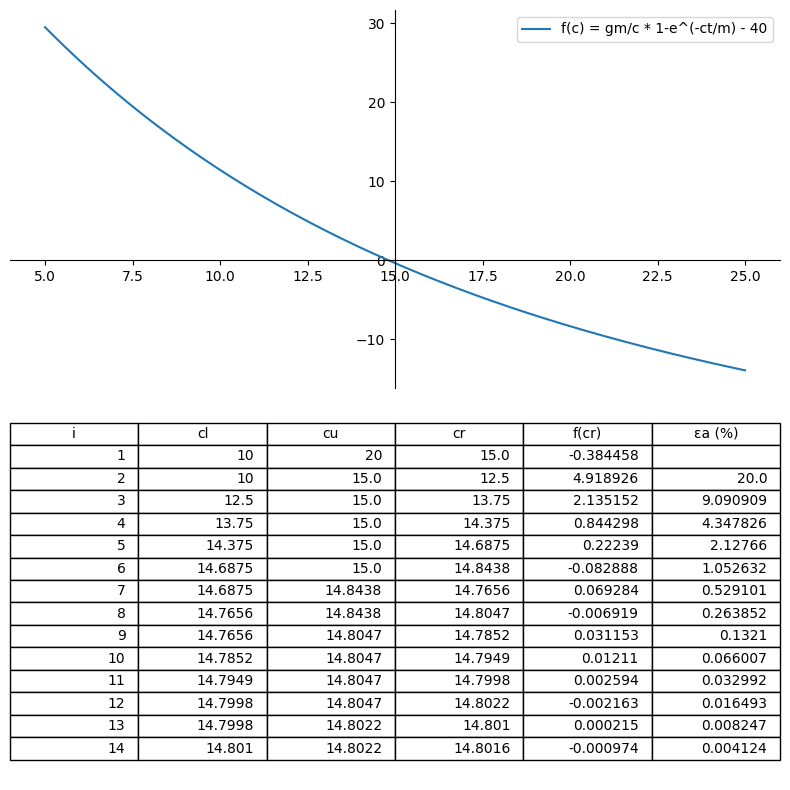

In [7]:
# função que define a velocidade de queda de um paraquedista
# queremos saber 1o, qual o valor de c, que se a gente botar na fórmula vai retornar 10
# v(t) = (gm/c) * (1-e^-(c*t/m)) onde:
    # m = 68,1 kg       (massa do paraquedista)
    # g = 9,81 m/s²     (aceleração da gravidade)
    # após t = 10s      (tempo em queda)
    # v = 40 m/s        (velocidade da queda)
    # c = ?             (coeficiente de resistência do ar)

# pra usar nossos métodos de aproximação, precisamos transformar isso em um problema de achar a raiz
# ou seja qual valor de de c pra f(c) = v(10) - 40 retornar 0

def f(c):
    m = 68.1
    g = 9.81
    t = 10

    # np.exp já calcula euler ^ alguma coisa. np.exp(alguma coisa)
    # isso aqui é uma inversão matemática da fórmula, a gente quer 0(f(c)) = esse return
    # basicamente botar no papel e trocar os valores
    return (g * m / c) * (1 - np.exp(-c*t/m)) - 40

# região da raiz é +- no c = 14.8
# plotei o grafo, e anotei.
# Movi o código de plotagem pro final pra ficar + organizado

a = f(10)
b = f(20)
if a * b < 0:
    print(a, b)
    print('sinais opostos, há uma raiz no intervalo')

# Resposta da letra C
# a mudança de sinal é importante pro método da bissecção pois pelo teorema do valor intermediário
# se f é contínua nesse intervalo [a, b] e a e b possuem sinais opostos, então certamente a função corta o eixo x.

resultado, tabela_dados = bissection(f, 10, 20, 0.001)

xs = np.linspace(5, 25, 200)
ys = f(xs)

# plt.subplots(2,1...) cria uma figura com 2 linhas e 1 coluna de subgráficos
# figsize define o tamanho que a figura vai utilizar em polegadas por alguma razão
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(xs, ys, label="f(c) = gm/c * 1-e^(-ct/m) - 40")
ax1.spines["left"].set_position(("data", 15))
ax1.spines["bottom"].set_position("zero")
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.legend()

# i = número da iteração
# cl (c lower) = extremo inferior da iteração
# cu (c upper) = extremo superior da iteração
# cr (c root) = ponto médio candidato à ser raiz
# f(cr) = valor da função naquele croot. Retorna o quão próx de 0.
ax2.axis('off')
tabela = ax2.table(
    cellText=tabela_dados,
    colLabels=["i", "cl", "cu", "cr", "f(cr)", "εa (%)"],
    loc='center'
)

# Questão e
# c ~ 14,80 kg/s é o coeficiente de resistência do ar que faz o modelo bater com a velocidade medida (40 m/s aos 10s).
# Fisicamente, quanto maior o c, mais resistência o ar oferece, e menor é a velocidade do paraquedista
# é esse efeito que o paraquedas maximiza

plt.tight_layout() # ajusta o espaço do gráfico e da tabela automaticamente
plt.show()

## Exercício 2: Método da Falsa Posição (canal de Manning)

1.5717501682892487 157.17501682892487


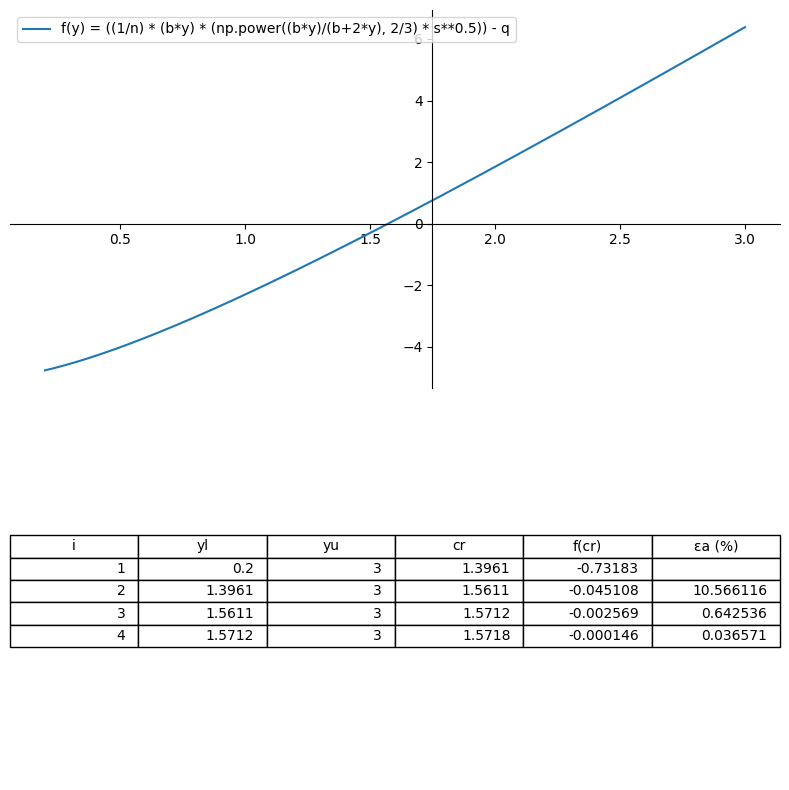

In [8]:
# vazão via equação de manning
# Q = 1/n * A * Rh^(2/3) * S^(1/2)
    # Q = vazão
    # A = área molhada = b * y
        # b = largura
        # y = profundidade da água
    # Rh = raio hidráulico = b*y / (b + 2*y)
    # S = declividade do canal
    # n = coeficiente de rugosidade

# y que zera a função é ~1.566 (conferindo no gráfico)
def f(y):
    n = 0.025
    b = 3
    s = 0.001
    q = 5
    return ((1/n) * (b*y) * (np.power((b*y)/(b+2*y), 2/3) * s**0.5)) - q

resultado, tabela_dados = falsepos(f, 0.2, 3, 0.001, 0.001)

xs = np.linspace(0.2, 3, 200)
ys = f(xs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(xs, ys, label="f(y) = ((1/n) * (b*y) * (np.power((b*y)/(b+2*y), 2/3) * s**0.5)) - q")
ax1.spines["left"].set_position(("data", 1.75))
ax1.spines["right"].set_visible(False)
ax1.spines["bottom"].set_position("zero")
ax1.spines["top"].set_visible(False)
ax1.legend()

ax2.axis('off')
# útil guardar a tabela numa variável se eu quiser alterar algo dps
# pode acabar dando problema nesse método por q ele pode retornar tabela_dados vazia. Mas pra esse caso específico ta de boa
tabela = ax2.table(
    cellText = tabela_dados,
    colLabels = ["i", "yl", "yu", "cr", "f(cr)", "εa (%)"],
    loc = 'center'
)

# Questão D
# por que o método da falsa posição estima a posição do próximo candidato de maneira diferente
# do método da bissecção. Enquanto a bissecção divide o intervalo sempre no meio, a falsa posição
# usa uma reta secante e pega onde o y=0, então se f(a) tá mais perto 0 q f(b) por exemplo, o
# ponto calculado fica mais próximo de a, e vice-versa.
# Dai surge a diferença nas aproximações. Um pega sempre pela metade, o outro pondera quem ta mais perto.

# Questão E
y_metros = resultado
y_cm = y_metros * 100
print(y_metros, y_cm)

# y ~ 1,57 m (157,18 cm) é a profundidade mínima de água necessária pro canal escoar 5,0 m³/s.
# Como é mais da metade da largura do canal (3,0 m), indica um canal relativamente profundo
# na prática, ainda se somaria uma margem de segurança acima desse valor.

plt.tight_layout()
plt.show()

## Exercício 3: Método de Newton-Raphson (van der Waals)

4.209260846948122


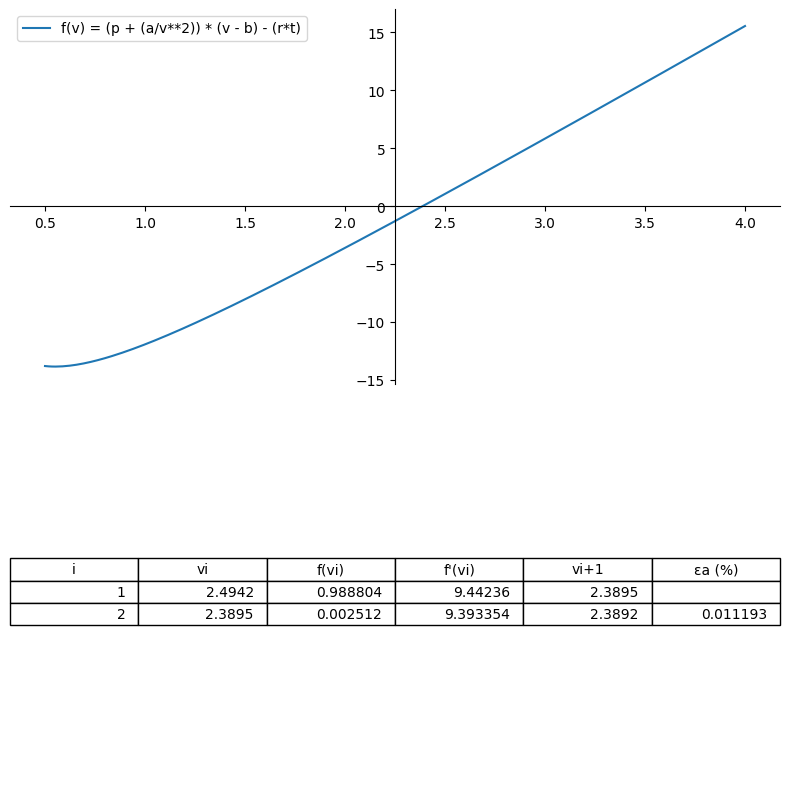

In [9]:
# corta o eixo x em ~2.38
def f(v):
    t = 300
    p = 10
    a = 3.592
    b = 0.04267
    r = 0.08314

    return  (p + (a/v**2)) * (v - b) - (r*t)

# builder da expressão simbólica pra biblioteca (mesma fórmula de f, em versão sympy)
def f_expr(symb_v):
    p, a, b, r, t = 10, 3.592, 0.04267, 0.08314, 300
    return (p + (a/symb_v**2)) * (symb_v - b) - (r*t)

# main

# fisicamente o comportamento real do Co2 não se desvia do comportamento ideal ou seja
# a fórmula dos gases ideais (rt/p) já é uma estimativa próxima da raiz, o que favorece a convergência rápida
# e estável do newton-raphson (q depende do chute inicial estar numa vizinhança próxima da solução)
v_ideal = (0.08314*300)/10
resultado, tabela_dados = newtonraphson(f, v_ideal, 0.001, 0.001, f_expr)

# resposta da letra e
# O desvio de aproximadamente 4,21% entre o volume real (calculado pelo Newton-Raphson)
# e o volume ideal confirma que a hipótese de gás ideal, embora seja uma simplificação, ainda é uma aproximação razoável nas condições do problema
# Ou seja o desvio entre comportamento ideal e real do gás é perceptível mas n é extremo

dif_perc = abs(resultado - v_ideal) / v_ideal * 100
print(dif_perc) # ~4.21

xs = np.linspace(0.5, 4, 200)
ys = f(xs)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))

ax1.plot(xs, ys, label="f(v) = (p + (a/v**2)) * (v - b) - (r*t)")
ax1.spines["left"].set_position(("data", 2.25))
ax1.spines["bottom"].set_position("zero")
ax1.spines["right"].set_visible(False)
ax1.spines["top"].set_visible(False)
ax1.legend()

ax2.axis('off')
tabela = ax2.table(
    cellText = tabela_dados,
    colLabels = ["i", "vi", "f(vi)", "f'(vi)", "vi+1", "εa (%)"],
    loc = 'center'
)

plt.tight_layout()
plt.show()

## Exercício 4: Método da Secante (circuito com diodo)

1
0.965311338436246


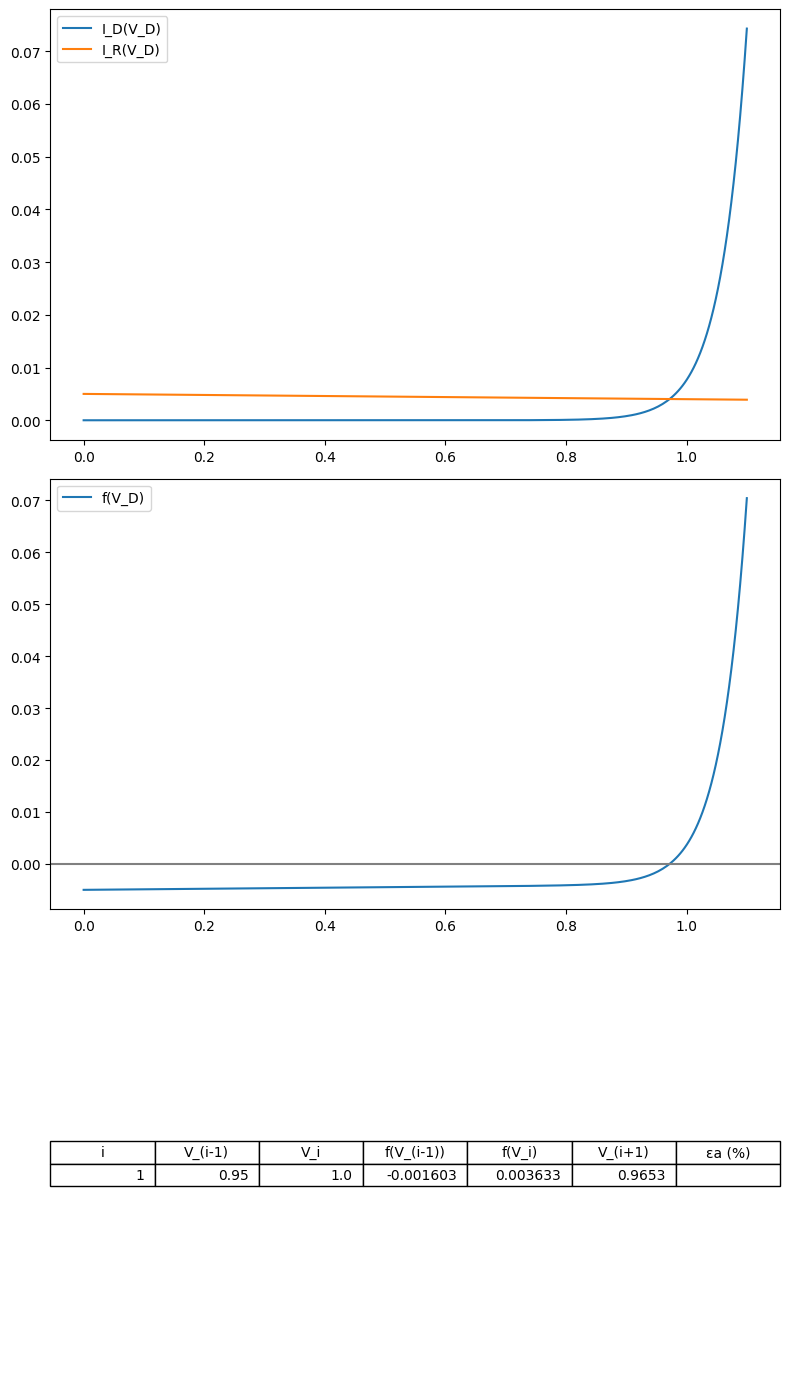

In [10]:
def f(vd):
    vs = 5
    r = 1000
    sat_i = 1 * 10**(-12)
    n = 1.7
    vt = 25.85 * 10**(-3)

    return (sat_i * (np.exp(vd/(n*vt)) - 1)) - ((vs - vd)/r)

# main
vd_vals = np.linspace(0, 1.1, 300)

vs = 5
r = 1000
sat_i = 1 * 10**(-12)
n = 1.7
vt = 25.85 * 10**(-3)

Id_vals = sat_i * (np.exp(vd_vals/(n*vt)) - 1)
Ir_vals = (vs - vd_vals) / r

resultado, tabela_dados = secant(f, 0.95, 1.00, 0.001, 0.001)
print(resultado)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 14))

# LETRA B
# A interseção das curvas é o ponto de operação real do circuito
# onde a corrente que o diodo permite passar coincide com a que a fonte/resistor fornecem,
# já que num circuito série só existe uma corrente.

# gráfico 1: I_D e I_R no mesmo sistema de coordenadas
ax1.plot(vd_vals, Id_vals, label="I_D(V_D)")
ax1.plot(vd_vals, Ir_vals, label="I_R(V_D)")
ax1.legend()

# gráfico 2: f(V_D)
ys = f(vd_vals)
ax2.plot(vd_vals, ys, label="f(V_D)")
ax2.axhline(0, color="gray")
ax2.legend()

# item d: tabela
ax3.axis('off')
ax3.table(
    cellText = tabela_dados,
    colLabels =["i", "V_(i-1)", "V_i", "f(V_(i-1))", "f(V_i)", "V_(i+1)", "εa (%)"],
    loc ='center'
)

# Letra E
# Vantagem: a secante não precisa da derivada exata, só aproxima com dois pontos.
# Desvantagem: converge um pouco mais devagar que Newton-Raphson,
# e diferente da falsa posição, não garante que a raiz continue cercada pelo intervalo (pode divergir)

plt.tight_layout()
plt.show()